## 7.21 광화학과 빛-물질 상호작용 입문

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_vector
from qiskit.quantum_info import Statevector

%matplotlib inline

In [2]:
# 계 매개변수 정의
omega_q = 1.0  # 큐비트(원자) 주파수
omega_c = 1.0  # 공동(광자) 주파수
g = 0.1        # 결합 세기
t = np.pi / (2 * g)  # 진화 시간

In [3]:
# 양자회로 생성 (원자-빛 상호작용을 모사하는 1큐비트)
qc_bloch = QuantumCircuit(1)
qc_bloch.h(0)  # 초기 상태 준비: |+> 상태(중첩)
qc_bloch.rz(omega_q * t, 0)
qc_bloch.rx(2 * g * t, 0)

In [4]:
# 블로흐 구 시각화
state = Statevector(qc_bloch)
bloch_vector = state.probabilities()

In [5]:
# 블로흐 벡터 성분 계산
theta = 2 * g * t
phi = omega_q * t
bloch_vec = [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]

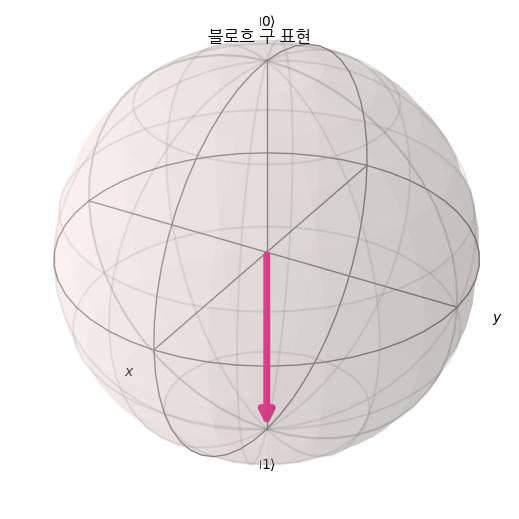

In [6]:
# 블로흐 벡터 플롯
plot_bloch_vector(bloch_vec)
plt.title("블로흐 구 표현")
plt.show()

In [7]:
# 측정을 위한 별도 회로 생성
qc = QuantumCircuit(1)
qc.h(0)
qc.rz(omega_q * t, 0)
qc.rx(2 * g * t, 0)
qc.measure_all()

In [8]:
# AerSimulator로 시뮬레이션
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()
counts = result.get_counts()

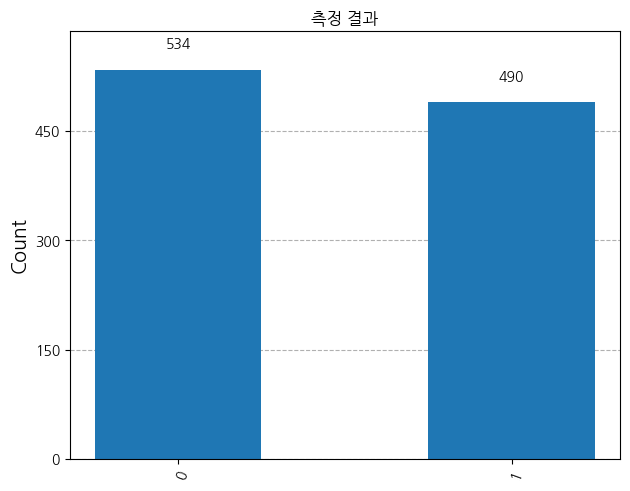

In [9]:
# 측정 결과 플롯
plot_histogram(counts)
plt.title("측정 결과")
plt.show()

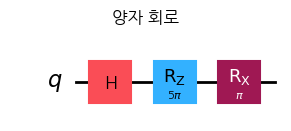

In [10]:
# 회로 시각화
qc_bloch.draw('mpl')
plt.title("양자 회로")
plt.show()